# 02 — Modelado · Separar train/test


Split elegido: **80/20 estratificado**. El 20% de test se prioriza para que la estimación final tenga suficientes ictus (~50) y sea estable. La validación cruzada, cuando llegue, subdivide el 80% de train — no crea un tercer bloque.

In [1]:
import pandas as pd
from sklearn.model_selection import train_test_split

In [2]:
df = pd.read_csv("../data/raw/stroke_dataset.csv")
df.shape

(4981, 11)

## Features y target

In [3]:


X = df.drop(columns="stroke")
y = df["stroke"]



## Split estratificado 80/20

- `test_size=0.20`: 20% al test.
- `stratify=y`: fuerza la proporción de ictus (~5%) en **ambos** lados. 
- `random_state=42`: fija el sorteo → mismo split en cada corrida (reproducible).

In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    stratify=y,
    random_state=42,
)

## Chequeo de estratificación

In [5]:
resumen = pd.DataFrame(
    {
        "n_filas": [len(y), len(y_train), len(y_test)],
        "n_ictus": [int(y.sum()), int(y_train.sum()), int(y_test.sum())],
        "prop_ictus": [y.mean(), y_train.mean(), y_test.mean()],
    },
    index=["original", "train", "test"],
)
resumen

,n_filas,n_ictus,prop_ictus
original,4981,248,0.049789
train,3984,198,0.049699
test,997,50,0.050150


## Aplicar drops (variables descartadas en el EDA)

Cuatro categóricas se descartaron por planas (`gender`, `Residence_type`) o proxy de edad (`ever_married`, `work_type`).

In [6]:
descartar = ["gender", "Residence_type", "ever_married", "work_type"]

X_train = X_train.drop(columns=descartar)
X_test  = X_test.drop(columns=descartar)

print(X_train.columns.tolist())

['age', 'hypertension', 'heart_disease', 'avg_glucose_level', 'bmi', 'smoking_status']


## Codificar smoking_status (one-hot)

Única categórica que sobrevive el drop (`gender`, `Residence_type`, `ever_married`, `work_type` se descartaron por planas o proxy de edad). Es **nominal** (sin orden) → one-hot, no ordinal.

`Unknown` va como categoría de **referencia** (todo-ceros, `drop="Unknown"`): los niveles informativos conservan su peso propio y una fila `Unknown` no aporta señal de tabaquismo — el modelo se apoya en el resto. Decisión conservadora para una herramienta de riesgo desplegable, donde un `Unknown` futuro puede corresponder a un niño pequeño.



In [7]:
from sklearn.preprocessing import OneHotEncoder

encoder = OneHotEncoder(
    categories=[["never smoked", "smokes", "formerly smoked", "Unknown"]],
    drop=["Unknown"],
    sparse_output=False,
    handle_unknown="error",
)

smk_train = encoder.fit_transform(X_train[["smoking_status"]])
smk_test  = encoder.transform(X_test[["smoking_status"]])

## Chequeo — one-hot de smoking_status

Confirmar con la salida real: 3 columnas (4 niveles − 1 baseline) y toda fila `Unknown` sumando 0.

In [8]:
import pandas as pd

cols = encoder.get_feature_names_out(["smoking_status"])
smk_train_df = pd.DataFrame(smk_train, columns=cols, index=X_train.index)

# ¿las filas Unknown quedaron todas en cero?
mask_unknown = X_train["smoking_status"] == "Unknown"
print("columnas:", list(cols))
print("filas Unknown todas en cero:", (smk_train_df[mask_unknown].sum(axis=1) == 0).all())
print(smk_train_df.head())

columnas: ['smoking_status_never smoked', 'smoking_status_smokes', 'smoking_status_formerly smoked']
filas Unknown todas en cero: True
      smoking_status_never smoked  smoking_status_smokes  \
4428                          0.0                    1.0   
1135                          0.0                    0.0   
2417                          0.0                    1.0   
1173                          1.0                    0.0   
3696                          1.0                    0.0   

      smoking_status_formerly smoked  
4428                             0.0  
1135                             0.0  
2417                             0.0  
1173                             0.0  
3696                             0.0  


In [9]:
X_train_final = X_train.drop(columns="smoking_status").join(smk_train_df)

smk_test_df = pd.DataFrame(smk_test, columns=cols, index=X_test.index)
X_test_final = X_test.drop(columns="smoking_status").join(smk_test_df)

print(X_train_final.shape, X_test_final.shape)
print(X_train_final.columns.tolist())

(3984, 8) (997, 8)
['age', 'hypertension', 'heart_disease', 'avg_glucose_level', 'bmi', 'smoking_status_never smoked', 'smoking_status_smokes', 'smoking_status_formerly smoked']


## Baseline — Regresión logística (pipeline)



In [10]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

numericas = ["age", "avg_glucose_level", "bmi"]

preprocesado = ColumnTransformer(
    transformers=[("num", StandardScaler(), numericas)],
    remainder="passthrough",
)

modelo_log = Pipeline(steps=[
    ("prep", preprocesado),
    ("clf", LogisticRegression(class_weight="balanced", max_iter=1000)),
])

In [11]:
from sklearn.metrics import classification_report, confusion_matrix

modelo_log.fit(X_train_final, y_train)
pred = modelo_log.predict(X_test_final)

print(confusion_matrix(y_test, pred))
print(classification_report(y_test, pred, digits=3))

[[701 246]
 [  8  42]]
              precision    recall  f1-score   support

           0      0.989     0.740     0.847       947
           1      0.146     0.840     0.249        50

    accuracy                          0.745       997
   macro avg      0.567     0.790     0.548       997
weighted avg      0.946     0.745     0.817       997



In [12]:
from sklearn.metrics import classification_report
print("TRAIN:\n", classification_report(y_train, modelo_log.predict(X_train_final), digits=3))

TRAIN:
               precision    recall  f1-score   support

           0      0.987     0.730     0.839      3786
           1      0.137     0.818     0.234       198

    accuracy                          0.734      3984
   macro avg      0.562     0.774     0.537      3984
weighted avg      0.945     0.734     0.809      3984



## XGBoost 

Ensemble de boosting. Suele ganar en datos tabulares. Debe superar el recall 0.84 del baseline para justificar su complejidad.

El desbalance se maneja con `scale_pos_weight`. 

In [13]:
n_neg = (y_train == 0).sum()
n_pos = (y_train == 1).sum()
scale_pos_weight = n_neg / n_pos

print(f"sanos: {n_neg} · ictus: {n_pos} · scale_pos_weight: {scale_pos_weight:.2f}")

sanos: 3786 · ictus: 198 · scale_pos_weight: 19.12


In [14]:
from xgboost import XGBClassifier

modelo_xgb = Pipeline(steps=[
    ("prep", preprocesado),
    ("clf", XGBClassifier(
        n_estimators=200,
        max_depth=3,
        learning_rate=0.1,
        scale_pos_weight=scale_pos_weight,
        eval_metric="logloss",
        random_state=42,
    )),
])

In [15]:
modelo_xgb.fit(X_train_final, y_train)
pred_xgb = modelo_xgb.predict(X_test_final)

print(confusion_matrix(y_test, pred_xgb))
print(classification_report(y_test, pred_xgb, digits=3))

[[787 160]
 [ 21  29]]
              precision    recall  f1-score   support

           0      0.974     0.831     0.897       947
           1      0.153     0.580     0.243        50

    accuracy                          0.818       997
   macro avg      0.564     0.706     0.570       997
weighted avg      0.933     0.818     0.864       997



## XGBoost — ajuste manual exploratorio

El XGBoost de fábrica (v1) quedó subentrenado para la clase ictus (recall 0.58 < 0.84 del baseline): árboles demasiado simples (`max_depth=3`) para un patrón sutil de 198 casos.

Prueba manual aflojando los frenos: subir capacidad (`max_depth` 3→5) y acompañar con pasos más finos (`learning_rate` 0.1→0.05) y más árboles (`n_estimators` 200→400). 
Objetivo: ver si el recall reacciona. El tuning sistemático (Optuna) es un paso posterior.

In [16]:
modelo_xgb_v2 = Pipeline(steps=[
    ("prep", preprocesado),
    ("clf", XGBClassifier(
        n_estimators=400,
        max_depth=5,
        learning_rate=0.05,
        scale_pos_weight=scale_pos_weight,
        eval_metric="logloss",
        random_state=42,
    )),
])

modelo_xgb_v2.fit(X_train_final, y_train)
pred_v2 = modelo_xgb_v2.predict(X_test_final)

print(confusion_matrix(y_test, pred_v2))
print(classification_report(y_test, pred_v2, digits=3))

[[862  85]
 [ 36  14]]
              precision    recall  f1-score   support

           0      0.960     0.910     0.934       947
           1      0.141     0.280     0.188        50

    accuracy                          0.879       997
   macro avg      0.551     0.595     0.561       997
weighted avg      0.919     0.879     0.897       997



## XGBoost — ajuste manual: subir scale_pos_weight

El primer ajuste (v2) subió la complejidad (`max_depth` 3→5) y el recall EMPEORÓ (0.58 → 0.28): con desbalance, más capacidad ayuda a la clase mayoritaria (sanos), no al ictus. El diagnóstico cambia: la perilla que mueve el recall es el peso de la clase minoritaria, no la complejidad.

Segunda prueba: volver a árboles simples (`max_depth=3`) y exagerar `scale_pos_weight` por encima del ratio real (19 → 35). Esperado: recall ↑, precision ↓.

In [17]:
modelo_xgb_v3 = Pipeline(steps=[
    ("prep", preprocesado),
    ("clf", XGBClassifier(
        n_estimators=200,
        max_depth=3,
        learning_rate=0.1,
        scale_pos_weight=35,
        eval_metric="logloss",
        random_state=42,
    )),
])

modelo_xgb_v3.fit(X_train_final, y_train)
pred_v3 = modelo_xgb_v3.predict(X_test_final)

print(confusion_matrix(y_test, pred_v3))
print(classification_report(y_test, pred_v3, digits=3))

[[737 210]
 [ 13  37]]
              precision    recall  f1-score   support

           0      0.983     0.778     0.869       947
           1      0.150     0.740     0.249        50

    accuracy                          0.776       997
   macro avg      0.566     0.759     0.559       997
weighted avg      0.941     0.776     0.838       997



## Validación cruzada estratificada

 La CV mide cada modelo en 5 particiones estratificadas de train y devuelve media ± desvío → estimación estable del recall/F1, no un golpe de suerte.

- `StratifiedKFold(5)`: cada fold conserva el ~5% de ictus (clave con la clase minoritaria tan chica).
- Los modelos ya son pipelines → la CV re-fitea el preprocesado dentro de cada fold, sin leakage entre folds.

In [18]:
from sklearn.model_selection import StratifiedKFold, cross_validate

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

scoring = ["recall", "f1"]

cv_log = cross_validate(
    modelo_log, X_train_final, y_train,
    cv=cv, scoring=scoring,
)

print("BASELINE (logística)")
print(f"  recall: {cv_log['test_recall'].mean():.3f} ± {cv_log['test_recall'].std():.3f}")
print(f"  f1:     {cv_log['test_f1'].mean():.3f} ± {cv_log['test_f1'].std():.3f}")

BASELINE (logística)
  recall: 0.813 ± 0.052
  f1:     0.235 ± 0.017


In [19]:
cv_xgb = cross_validate(
    modelo_xgb_v3, X_train_final, y_train,
    cv=cv, scoring=scoring,
)

print("XGBoost v3 (peso 35)")
print(f"  recall: {cv_xgb['test_recall'].mean():.3f} ± {cv_xgb['test_recall'].std():.3f}")
print(f"  f1:     {cv_xgb['test_f1'].mean():.3f} ± {cv_xgb['test_f1'].std():.3f}")

XGBoost v3 (peso 35)
  recall: 0.637 ± 0.073
  f1:     0.220 ± 0.027


## Optuna — tuning de XGBoost 

Optimización bayesiana

Objetivo: F1, para evitar el colapso de "recall puro". El test queda intacto: la búsqueda vive solo en train, medida por CV.

Espacio de búsqueda informado por los ajustes manuales: subir `max_depth` perjudicó, así que su rango arranca bajo; `scale_pos_weight` fue la perilla que movió el recall, se explora ancho.

In [20]:
import optuna
from sklearn.model_selection import cross_val_score

def objective(trial):
    params = {
        "n_estimators": trial.suggest_int("n_estimators", 100, 500),
        "max_depth": trial.suggest_int("max_depth", 2, 6),
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.3, log=True),
        "scale_pos_weight": trial.suggest_float("scale_pos_weight", 10, 45),
    }
    modelo = Pipeline(steps=[
        ("prep", preprocesado),
        ("clf", XGBClassifier(**params, eval_metric="logloss", random_state=42)),
    ])
    scores = cross_val_score(modelo, X_train_final, y_train, cv=cv, scoring="f1")
    return scores.mean()

In [21]:
optuna.logging.set_verbosity(optuna.logging.WARNING)

study = optuna.create_study(direction="maximize")
study.optimize(objective, n_trials=30)

print("Mejor F1 (CV):", round(study.best_value, 3))
print("Mejores parámetros:", study.best_params)

Mejor F1 (CV): 0.257
Mejores parámetros: {'n_estimators': 141, 'max_depth': 2, 'learning_rate': 0.03351784435924333, 'scale_pos_weight': 10.268499726630036}


In [23]:
modelo_xgb_opt = Pipeline(steps=[
    ("prep", preprocesado),
    ("clf", XGBClassifier(**study.best_params, eval_metric="logloss", random_state=42)),
])

cv_opt = cross_validate(
    modelo_xgb_opt, X_train_final, y_train,
    cv=cv, scoring=["recall", "f1"],
)

print("XGBoost tuneado (Optuna, objetivo F1)")
print(f"  recall: {cv_opt['test_recall'].mean():.3f} ± {cv_opt['test_recall'].std():.3f}")
print(f"  f1:     {cv_opt['test_f1'].mean():.3f} ± {cv_opt['test_f1'].std():.3f}")

XGBoost tuneado (Optuna, objetivo F1)
  recall: 0.612 ± 0.100
  f1:     0.257 ± 0.029


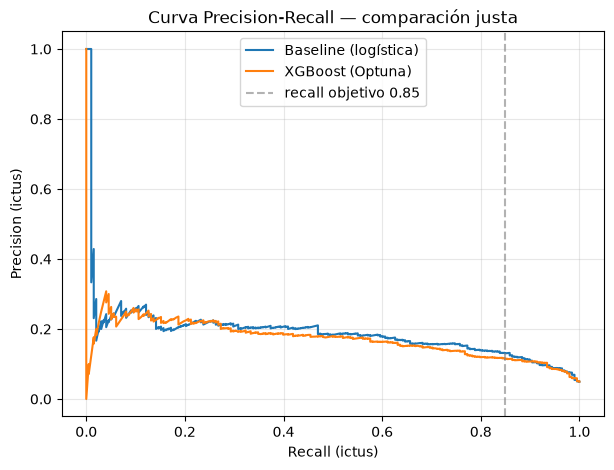

In [24]:
from sklearn.model_selection import cross_val_predict
from sklearn.metrics import precision_recall_curve
import matplotlib.pyplot as plt

# probabilidades por CV (sin leakage: cada fila predicha por un fold que no la vio)
proba_log = cross_val_predict(modelo_log,     X_train_final, y_train, cv=cv, method="predict_proba")[:, 1]
proba_xgb = cross_val_predict(modelo_xgb_opt, X_train_final, y_train, cv=cv, method="predict_proba")[:, 1]

prec_log, rec_log, _ = precision_recall_curve(y_train, proba_log)
prec_xgb, rec_xgb, _ = precision_recall_curve(y_train, proba_xgb)

plt.figure(figsize=(7, 5))
plt.plot(rec_log, prec_log, label="Baseline (logística)")
plt.plot(rec_xgb, prec_xgb, label="XGBoost (Optuna)")
plt.axvline(0.85, color="gray", linestyle="--", alpha=0.6, label="recall objetivo 0.85")
plt.xlabel("Recall (ictus)")
plt.ylabel("Precision (ictus)")
plt.title("Curva Precision-Recall — comparación justa")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

In [25]:
import optuna
from sklearn.model_selection import cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression

def objetivo_logistica(trial):
    C = trial.suggest_float("C", 1e-3, 1e3, log=True)
    modelo = Pipeline(steps=[
        ("prep", preprocesado),
        ("clf", LogisticRegression(C=C, class_weight="balanced", max_iter=1000)),
    ])
    scores = cross_val_score(modelo, X_train_final, y_train,
                             cv=cv, scoring="average_precision")
    return scores.mean()

optuna.logging.set_verbosity(optuna.logging.WARNING)
estudio_log = optuna.create_study(direction="maximize")
estudio_log.optimize(objetivo_logistica, n_trials=30)

print("Mejor C:", estudio_log.best_params["C"])
print("Mejor average precision (CV):", round(estudio_log.best_value, 3))

Mejor C: 0.0059176463133363034
Mejor average precision (CV): 0.208


In [26]:
from sklearn.model_selection import cross_val_score

baseline = Pipeline(steps=[
    ("prep", preprocesado),
    ("clf", LogisticRegression(C=1.0, class_weight="balanced", max_iter=1000)),
])
ap_base = cross_val_score(baseline, X_train_final, y_train,
                          cv=cv, scoring="average_precision").mean()
print("AP baseline (C=1.0):", round(ap_base, 3), "| AP tuneado:", 0.208)

AP baseline (C=1.0): 0.201 | AP tuneado: 0.208


In [27]:
import numpy as np
from sklearn.model_selection import cross_val_predict
from sklearn.metrics import precision_recall_curve

modelo_final = Pipeline(steps=[
    ("prep", preprocesado),
    ("clf", LogisticRegression(C=0.0059, class_weight="balanced", max_iter=1000)),
])

proba_oof = cross_val_predict(modelo_final, X_train_final, y_train,
                              cv=cv, method="predict_proba")[:, 1]

prec, rec, thr = precision_recall_curve(y_train, proba_oof)

print("umbral | recall | precisión")
for p, r, t in zip(prec, rec, thr):
    if 0.85 <= r <= 0.90:
        print(f"{t:.3f}  |  {r:.3f}  |  {p:.3f}")

umbral | recall | precisión
0.424  |  0.899  |  0.113
0.424  |  0.899  |  0.114
0.424  |  0.899  |  0.114
0.424  |  0.899  |  0.114
0.424  |  0.894  |  0.113
0.424  |  0.894  |  0.113
0.424  |  0.894  |  0.113
0.425  |  0.889  |  0.113
0.425  |  0.884  |  0.112
0.425  |  0.884  |  0.112
0.426  |  0.884  |  0.112
0.426  |  0.884  |  0.112
0.426  |  0.884  |  0.112
0.426  |  0.884  |  0.112
0.426  |  0.884  |  0.113
0.426  |  0.884  |  0.113
0.426  |  0.884  |  0.113
0.427  |  0.884  |  0.113
0.427  |  0.884  |  0.113
0.427  |  0.884  |  0.113
0.427  |  0.884  |  0.113
0.427  |  0.884  |  0.113
0.428  |  0.884  |  0.113
0.428  |  0.884  |  0.113
0.428  |  0.884  |  0.113
0.428  |  0.884  |  0.113
0.429  |  0.879  |  0.113
0.429  |  0.879  |  0.113
0.429  |  0.879  |  0.113
0.429  |  0.879  |  0.113
0.429  |  0.879  |  0.113
0.429  |  0.879  |  0.113
0.429  |  0.879  |  0.113
0.430  |  0.879  |  0.113
0.430  |  0.879  |  0.113
0.430  |  0.879  |  0.113
0.430  |  0.879  |  0.114
0.430  |  

In [28]:
from sklearn.metrics import recall_score, precision_score, confusion_matrix, classification_report

modelo_final.fit(X_train_final, y_train)

proba_test = modelo_final.predict_proba(X_test_final)[:, 1]

UMBRAL = 0.43
y_pred = (proba_test >= UMBRAL).astype(int)

print("Umbral:", UMBRAL)
print("Recall   :", round(recall_score(y_test, y_pred), 3))
print("Precisión:", round(precision_score(y_test, y_pred), 3))
print()
print(confusion_matrix(y_test, y_pred))
print()
print(classification_report(y_test, y_pred, digits=3))

Umbral: 0.43
Recall   : 0.9
Precisión: 0.127

[[639 308]
 [  5  45]]

              precision    recall  f1-score   support

           0      0.992     0.675     0.803       947
           1      0.127     0.900     0.223        50

    accuracy                          0.686       997
   macro avg      0.560     0.787     0.513       997
weighted avg      0.949     0.686     0.774       997



## GAM — tratamiento no lineal de glucosa y bmi

El modelo ganador (logística `C=0.0059`) asigna **una sola pendiente por variable**.
Ante un efecto no lineal esto subestima por construcción: no puede doblarse en un codo.
El EDA marcó dos variables con esa forma → `avg_glucose_level` (umbral ~150) y
`bmi` (meseta/salto, invisible a Pearson 0.057 justamente por no ser lineal).

Un **GAM** conserva la estructura aditiva de la logística pero deja que cada variable
tenga su propia forma: recta donde alcanza, curva suave (spline) donde hace falta.
Reparto de términos:

- `s()` (spline) → `avg_glucose_level`, `bmi`
- `l()` (lineal) → `age` (monótona), binarias y dummies de `smoking_status`

El freno de cada spline es `λ` (penaliza la curvatura): `λ` alto = curva suave,
`λ` bajo = curva libre. Con 198 eventos se espera que la CV empuje a `λ` alto,
igual que `C` empujó a más regularización.

**Fit #1 con `λ` por defecto** — objetivo: ver la forma de las curvas antes de tunear.
Mismo split train/test que el modelo ganador (reusa `X_train.index` / `X_test.index`).

In [32]:
import pandas as pd

SMOKE_COLS = ["formerly smoked", "never smoked", "smokes"]  # Unknown = referencia

print("categorías reales:", sorted(X_train["smoking_status"].unique()))

def build_gam_matrix(X):
    dummies = pd.get_dummies(X["smoking_status"]).reindex(columns=SMOKE_COLS, fill_value=0).astype(int)
    assert dummies.to_numpy().sum() == (X["smoking_status"] != "Unknown").sum(), \
        "MISMATCH: nombres de categoría no coinciden con SMOKE_COLS"
    return pd.DataFrame({
        "age":               X["age"].to_numpy(),                 # 0 -> l
        "avg_glucose_level": X["avg_glucose_level"].to_numpy(),   # 1 -> s
        "bmi":               X["bmi"].to_numpy(),                 # 2 -> s
        "hypertension":      X["hypertension"].to_numpy(),        # 3 -> l
        "heart_disease":     X["heart_disease"].to_numpy(),       # 4 -> l
        "smoke_formerly":    dummies["formerly smoked"].to_numpy(),  # 5 -> l
        "smoke_never":       dummies["never smoked"].to_numpy(),     # 6 -> l
        "smoke_smokes":      dummies["smokes"].to_numpy(),           # 7 -> l
    }, index=X.index)

X_gam_train_df = build_gam_matrix(X_train)
X_gam_test_df  = build_gam_matrix(X_test)

X_gam_train = X_gam_train_df.to_numpy()
X_gam_test  = X_gam_test_df.to_numpy()

print("orden:", X_gam_train_df.columns.tolist())
print("shape:", X_gam_train.shape)
print("NaN por columna:\n", X_gam_train_df.isna().sum())

categorías reales: ['Unknown', 'formerly smoked', 'never smoked', 'smokes']
orden: ['age', 'avg_glucose_level', 'bmi', 'hypertension', 'heart_disease', 'smoke_formerly', 'smoke_never', 'smoke_smokes']
shape: (3984, 8)
NaN por columna:
 age                  0
avg_glucose_level    0
bmi                  0
hypertension         0
heart_disease        0
smoke_formerly       0
smoke_never          0
smoke_smokes         0
dtype: int64


In [39]:
from sklearn.preprocessing import StandardScaler
import numpy as np

CONT_IDX = [0, 1, 2]

scaler_gam = StandardScaler().fit(X_gam_train[:, CONT_IDX])

def scale_cont(M):
    M = M.astype(float).copy()
    M[:, CONT_IDX] = scaler_gam.transform(M[:, CONT_IDX])
    return M

X_gam_train_s = scale_cont(X_gam_train)
X_gam_test_s  = scale_cont(X_gam_test)

print("media≈0:", np.round(X_gam_train_s[:, CONT_IDX].mean(axis=0), 3))
print("std≈1  :", np.round(X_gam_train_s[:, CONT_IDX].std(axis=0), 3))

media≈0: [ 0.  0. -0.]
std≈1  : [1. 1. 1.]


In [38]:
from pygam import LogisticGAM, s, l
from sklearn.utils.class_weight import compute_sample_weight

terms = l(0) + s(1) + s(2) + l(3) + l(4) + l(5) + l(6) + l(7)
weights = compute_sample_weight(class_weight="balanced", y=y_train)

gam = LogisticGAM(terms).fit(X_gam_train_s, y_train, weights=weights)

print("NaN en probas:", np.isnan(gam.predict_proba(X_gam_train_s)).sum())
gam.summary()

c:\Users\arii_\Factoria F5\Proyectos\Proyecto8-Ari\.venv\Lib\site-packages\pygam\links.py:121: RuntimeWarning: overflow encountered in exp
  elp = np.exp(lp)
c:\Users\arii_\Factoria F5\Proyectos\Proyecto8-Ari\.venv\Lib\site-packages\pygam\links.py:122: RuntimeWarning: invalid value encountered in divide
  return dist.levels * elp / (elp + 1)
c:\Users\arii_\Factoria F5\Proyectos\Proyecto8-Ari\.venv\Lib\site-packages\pygam\links.py:137: RuntimeWarning: divide by zero encountered in divide
  return dist.levels / (mu * (dist.levels - mu))
c:\Users\arii_\Factoria F5\Proyectos\Proyecto8-Ari\.venv\Lib\site-packages\pygam\links.py:137: RuntimeWarning: overflow encountered in divide
  return dist.levels / (mu * (dist.levels - mu))
c:\Users\arii_\Factoria F5\Proyectos\Proyecto8-Ari\.venv\Lib\site-packages\pygam\pygam.py:631: RuntimeWarning: overflow encountered in square
  self.link.gradient(mu, self.distribution) ** 2
c:\Users\arii_\Factoria F5\Proyectos\Proyecto8-Ari\.venv\Lib\site-packages\py

NaN en probas: 0
LogisticGAM                                                                                               
=============================================== ==========================================================
Distribution:                      BinomialDist Effective DoF:                                      29.452
Link Function:                        LogitLink Log Likelihood:                                 -1957.2486
Number of Samples:                         3984 AIC:                                             3973.4013
                                                AICc:                                            3973.8859
                                                UBRE:                                               2.9531
                                                Scale:                                                 1.0
                                                Pseudo R-Squared:                                   0.6946
Feature Function    

C:\Users\arii_\AppData\Local\Temp\ipykernel_18240\3821014948.py:10: UserWarning: KNOWN BUG: p-values computed in this summary are likely much smaller than they should be. 
 
Please do not make inferences based on these values! 

Collaborate on a solution, and stay up to date at: 
github.com/dswah/pyGAM/issues/163 

  gam.summary()


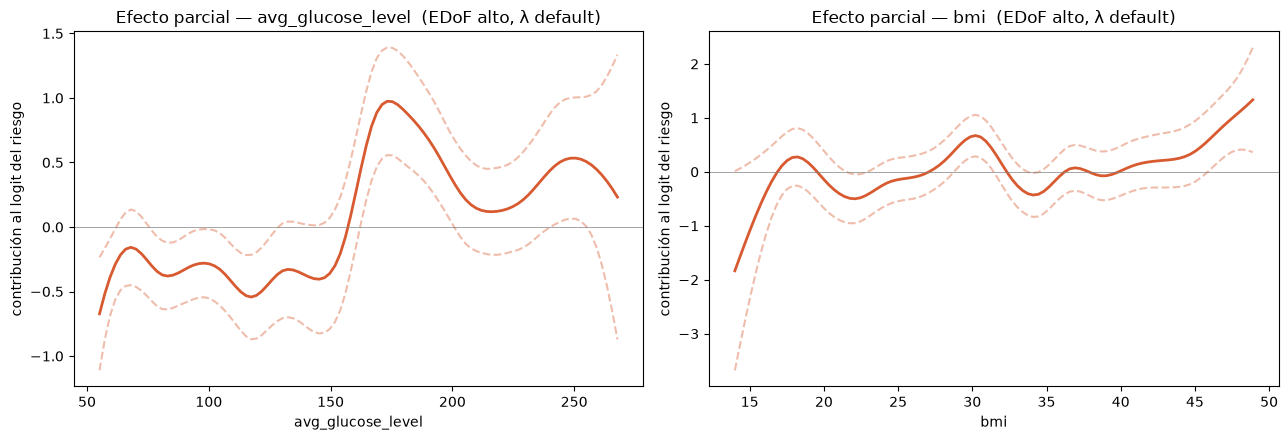

In [40]:
import matplotlib.pyplot as plt
import numpy as np

scaler_pos = {1: 1, 2: 2}  # glucosa -> pos 1 del scaler, bmi -> pos 2

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
for ax, (term, name) in zip(axes, [(1, "avg_glucose_level"), (2, "bmi")]):
    XX = gam.generate_X_grid(term=term)
    pdep, ci = gam.partial_dependence(term=term, X=XX, width=0.95)

    pos = scaler_pos[term]
    x_real = XX[:, term] * scaler_gam.scale_[pos] + scaler_gam.mean_[pos]

    ax.plot(x_real, pdep, color="#D85A30", lw=2)
    ax.plot(x_real, ci, color="#D85A30", ls="--", alpha=0.4)
    ax.axhline(0, color="gray", lw=0.5)
    ax.set_title(f"Efecto parcial — {name}  (EDoF alto, λ default)")
    ax.set_xlabel(name); ax.set_ylabel("contribución al logit del riesgo")

plt.tight_layout(); plt.show()

c:\Users\arii_\Factoria F5\Proyectos\Proyecto8-Ari\.venv\Lib\site-packages\pygam\links.py:121: RuntimeWarning: overflow encountered in exp
  elp = np.exp(lp)
c:\Users\arii_\Factoria F5\Proyectos\Proyecto8-Ari\.venv\Lib\site-packages\pygam\links.py:122: RuntimeWarning: invalid value encountered in divide
  return dist.levels * elp / (elp + 1)
c:\Users\arii_\Factoria F5\Proyectos\Proyecto8-Ari\.venv\Lib\site-packages\pygam\links.py:137: RuntimeWarning: divide by zero encountered in divide
  return dist.levels / (mu * (dist.levels - mu))
c:\Users\arii_\Factoria F5\Proyectos\Proyecto8-Ari\.venv\Lib\site-packages\pygam\links.py:137: RuntimeWarning: overflow encountered in divide
  return dist.levels / (mu * (dist.levels - mu))
c:\Users\arii_\Factoria F5\Proyectos\Proyecto8-Ari\.venv\Lib\site-packages\pygam\pygam.py:631: RuntimeWarning: overflow encountered in square
  self.link.gradient(mu, self.distribution) ** 2
c:\Users\arii_\Factoria F5\Proyectos\Proyecto8-Ari\.venv\Lib\site-packages\py

λ=1000 en avg_glucose_level: DIVERGIÓ, salteado (OptimizationError)


c:\Users\arii_\Factoria F5\Proyectos\Proyecto8-Ari\.venv\Lib\site-packages\pygam\links.py:121: RuntimeWarning: overflow encountered in exp
  elp = np.exp(lp)
c:\Users\arii_\Factoria F5\Proyectos\Proyecto8-Ari\.venv\Lib\site-packages\pygam\links.py:122: RuntimeWarning: invalid value encountered in divide
  return dist.levels * elp / (elp + 1)
c:\Users\arii_\Factoria F5\Proyectos\Proyecto8-Ari\.venv\Lib\site-packages\pygam\links.py:137: RuntimeWarning: divide by zero encountered in divide
  return dist.levels / (mu * (dist.levels - mu))
c:\Users\arii_\Factoria F5\Proyectos\Proyecto8-Ari\.venv\Lib\site-packages\pygam\links.py:137: RuntimeWarning: overflow encountered in divide
  return dist.levels / (mu * (dist.levels - mu))
c:\Users\arii_\Factoria F5\Proyectos\Proyecto8-Ari\.venv\Lib\site-packages\pygam\pygam.py:631: RuntimeWarning: overflow encountered in square
  self.link.gradient(mu, self.distribution) ** 2
c:\Users\arii_\Factoria F5\Proyectos\Proyecto8-Ari\.venv\Lib\site-packages\py

λ=1000 en bmi: DIVERGIÓ, salteado (OptimizationError)


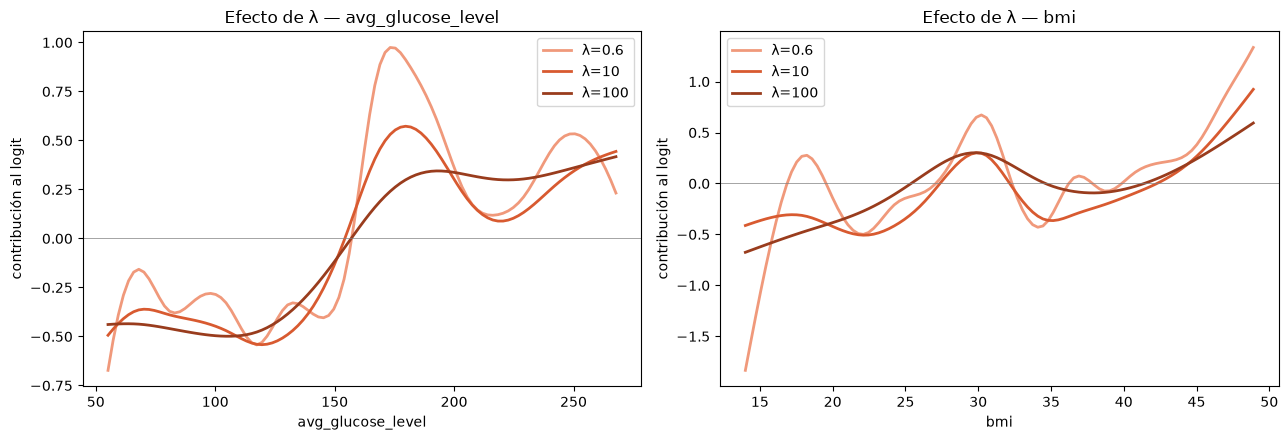

In [43]:
import matplotlib.pyplot as plt
import numpy as np

lams = [0.6, 10, 100, 1000]
colors = ["#F0997B", "#D85A30", "#993C1D", "#4A1B0C"]
base_terms = l(0)+s(1)+s(2)+l(3)+l(4)+l(5)+l(6)+l(7)

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
for ax, (term, name, pos) in zip(axes, [(1, "avg_glucose_level", 1), (2, "bmi", 2)]):
    for lam, col in zip(lams, colors):
        try:
            g = LogisticGAM(base_terms, lam=lam).fit(X_gam_train_s, y_train, weights=weights)
        except Exception as e:
            print(f"λ={lam} en {name}: DIVERGIÓ, salteado ({type(e).__name__})")
            continue
        XX = g.generate_X_grid(term=term)
        pdep = g.partial_dependence(term=term, X=XX)
        x_real = XX[:, term] * scaler_gam.scale_[pos] + scaler_gam.mean_[pos]
        ax.plot(x_real, pdep, color=col, lw=2, label=f"λ={lam}")
    ax.axhline(0, color="gray", lw=0.5)
    ax.set_title(f"Efecto de λ — {name}")
    ax.set_xlabel(name); ax.set_ylabel("contribución al logit")
    ax.legend()
plt.tight_layout(); plt.show()

In [44]:
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import average_precision_score
from sklearn.preprocessing import StandardScaler
from sklearn.utils.class_weight import compute_sample_weight
import numpy as np, warnings

y_arr     = np.asarray(y_train)
lam_grid  = [0.6, 2, 5, 10, 25, 50, 100]
CONT_IDX  = [0, 1, 2]
base_terms = l(0)+s(1)+s(2)+l(3)+l(4)+l(5)+l(6)+l(7)

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

resultados = {}
with warnings.catch_warnings():
    warnings.simplefilter("ignore")           # calla los warnings cosméticos del loop
    for lam in lam_grid:
        aps = []
        for tr, va in cv.split(X_gam_train, y_arr):
            sc  = StandardScaler().fit(X_gam_train[tr][:, CONT_IDX])   # escala SOLO con train del fold
            Xtr = X_gam_train[tr].astype(float).copy()
            Xva = X_gam_train[va].astype(float).copy()
            Xtr[:, CONT_IDX] = sc.transform(Xtr[:, CONT_IDX])
            Xva[:, CONT_IDX] = sc.transform(Xva[:, CONT_IDX])
            w = compute_sample_weight("balanced", y=y_arr[tr])
            try:
                g = LogisticGAM(base_terms, lam=lam).fit(Xtr, y_arr[tr], weights=w)
            except Exception:
                aps.append(np.nan); continue
            aps.append(average_precision_score(y_arr[va], g.predict_proba(Xva)))
        resultados[lam] = (np.nanmean(aps), np.nanstd(aps), int(np.sum(np.isnan(aps))))

print(f"{'λ':>6} | {'AP medio':>9} | {'±std':>7} | folds fallidos")
for lam, (m, s_, f) in resultados.items():
    print(f"{lam:>6} | {m:>9.4f} | {s_:>7.4f} | {f}")

     λ |  AP medio |    ±std | folds fallidos
   0.6 |    0.2098 |  0.0563 | 1
     2 |    0.2079 |  0.0605 | 1
     5 |    0.1791 |  0.0379 | 2
    10 |    0.1863 |  0.0346 | 1
    25 |    0.2015 |  0.0139 | 3
    50 |    0.2089 |  0.0525 | 0
   100 |    0.2098 |  0.0573 | 0


In [45]:
from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.utils.class_weight import compute_sample_weight
from sklearn.metrics import precision_recall_curve
import numpy as np, warnings

y_arr = np.asarray(y_train)
LAM_FINAL = 100
CONT_IDX = [0, 1, 2]
base_terms = l(0)+s(1)+s(2)+l(3)+l(4)+l(5)+l(6)+l(7)

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
oof_proba = np.zeros(len(y_arr))

with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    for tr, va in cv.split(X_gam_train, y_arr):
        sc = StandardScaler().fit(X_gam_train[tr][:, CONT_IDX])
        Xtr = X_gam_train[tr].astype(float).copy()
        Xva = X_gam_train[va].astype(float).copy()
        Xtr[:, CONT_IDX] = sc.transform(Xtr[:, CONT_IDX])
        Xva[:, CONT_IDX] = sc.transform(Xva[:, CONT_IDX])
        w = compute_sample_weight("balanced", y=y_arr[tr])
        g = LogisticGAM(base_terms, lam=LAM_FINAL).fit(Xtr, y_arr[tr], weights=w)
        oof_proba[va] = g.predict_proba(Xva)

prec, rec, thr = precision_recall_curve(y_arr, oof_proba)

print(f"{'umbral':>7} | {'recall':>7} | {'precisión':>9}")
for t in [0.35, 0.40, 0.43, 0.45, 0.50, 0.55, 0.60]:
    i = np.searchsorted(thr, t)
    if i < len(rec):
        print(f"{t:>7.2f} | {rec[i]:>7.3f} | {prec[i]:>9.3f}")

 umbral |  recall | precisión
   0.35 |   0.929 |     0.101
   0.40 |   0.884 |     0.110
   0.43 |   0.874 |     0.118
   0.45 |   0.848 |     0.121
   0.50 |   0.803 |     0.133
   0.55 |   0.758 |     0.148
   0.60 |   0.677 |     0.158


In [46]:
import numpy as np, warnings
from sklearn.metrics import recall_score, precision_score, confusion_matrix

LAM_FINAL = 100
THR_FINAL = 0.40
base_terms = l(0)+s(1)+s(2)+l(3)+l(4)+l(5)+l(6)+l(7)

with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    gam_final = LogisticGAM(base_terms, lam=LAM_FINAL).fit(
        X_gam_train_s, y_train, weights=weights)          # refit sobre TODO el train escalado

proba_test = gam_final.predict_proba(X_gam_test_s)         # UNA sola predicción sobre test
pred_test  = (proba_test >= THR_FINAL).astype(int)

rec  = recall_score(y_test, pred_test)
prec = precision_score(y_test, pred_test)
cm   = confusion_matrix(y_test, pred_test)

print(f"GAM final  (λ={LAM_FINAL}, umbral={THR_FINAL})")
print(f"  Recall    : {rec:.3f}")
print(f"  Precisión : {prec:.3f}")
print(f"  Matriz    : {cm.tolist()}")

GAM final  (λ=100, umbral=0.4)
  Recall    : 0.920
  Precisión : 0.126
  Matriz    : [[628, 319], [4, 46]]


## Tratamiento del desbalance — `class_weight` vs SMOTE

El desbalance 1:19 se puede tratar de dos formas: **reponderando** (`class_weight="balanced"`)
o **resampleando** la clase minoritaria con **SMOTE** (genera ictus sintéticos interpolando
entre ictus reales vecinos).

Objetivo: comparar las dos vías con el **mismo `C=0.0059`, misma CV estratificada y mismo
scoring (AP)** — manzanas con manzanas. No busca "romper el techo de datos" (SMOTE interpola
la señal existente, no agrega información real), sino verificar si una forma de tratar el
desbalance supera a la otra.

**Guardarraíl anti-leakage:** SMOTE va dentro de un `imblearn.Pipeline`, de modo que solo
resamplea el **train de cada fold**; la validación queda **real e intacta**.

**Resultado:** `class_weight` AP = 0.2038 ± 0.0467 · SMOTE AP = 0.1999 ± 0.0410 → diferencia
**−0.0039**, un orden de magnitud menor que el ±std → **ruido, no señal**. Las dos técnicas son
equivalentes; SMOTE incluso queda un pelín por debajo (ruido de interpolación). Cuarta
confirmación del techo de datos: **el límite lo pone la cantidad de información real, no la técnica.**

In [49]:
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import cross_val_score, StratifiedKFold
import numpy as np

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# A) el baseline : class_weight="balanced"
pipe_cw = ImbPipeline([
    ("scaler", StandardScaler()),
    ("clf", LogisticRegression(C=0.0059, class_weight="balanced", max_iter=1000)),
])

# B) SMOTE en vez de class_weight (mismo C, SIN class_weight)
pipe_smote = ImbPipeline([
    ("scaler", StandardScaler()),
    ("smote", SMOTE(random_state=42)),
    ("clf", LogisticRegression(C=0.0059, max_iter=1000)),
])

ap_cw    = cross_val_score(pipe_cw,    X_gam_train_df, y_train, cv=cv, scoring="average_precision")
ap_smote = cross_val_score(pipe_smote, X_gam_train_df, y_train, cv=cv, scoring="average_precision")

print(f"class_weight : AP = {ap_cw.mean():.4f} ± {ap_cw.std():.4f}")
print(f"SMOTE        : AP = {ap_smote.mean():.4f} ± {ap_smote.std():.4f}")
print(f"diferencia   : {ap_smote.mean() - ap_cw.mean():+.4f}")

class_weight : AP = 0.2038 ± 0.0467
SMOTE        : AP = 0.1999 ± 0.0410
diferencia   : -0.0039


In [50]:
import joblib
from pathlib import Path

MODELS_DIR = Path("../models")
MODELS_DIR.mkdir(exist_ok=True)

joblib.dump(modelo_final, MODELS_DIR / "logistic_stroke.joblib")
joblib.dump(encoder, MODELS_DIR / "smoking_encoder.joblib")

print("modelo:", (MODELS_DIR / "logistic_stroke.joblib").exists())
print("encoder:", (MODELS_DIR / "smoking_encoder.joblib").exists())

modelo: True
encoder: True


## Verificación anti-leakage — shuffle test (permutación de etiquetas)

Prueba de que el rendimiento del modelo de producción viene de señal real y no de una
fuga de información. Se reentrena el mismo pipeline sobre `y_train` **barajado** (se rompe
a propósito la relación X → y) y se mide sobre el test real. Si el modelo aprendía algo
auténtico, con etiquetas aleatorias su capacidad debe caer a nivel de azar.

- **Recall** (métrica del proyecto, umbral 0,43) se reporta para continuidad: cae desde 0,90
  hacia su nivel de azar.

20 permutaciones para tener media ± desvío del nivel nulo, no un único golpe de suerte.

In [52]:
import numpy as np
from sklearn.base import clone
from sklearn.metrics import roc_auc_score, average_precision_score

N_PERM = 100
rng    = np.random.default_rng(42)
y_tr   = np.asarray(y_train)

# --- Referencia: etiquetas REALES ---
modelo_final.fit(X_train_final, y_train)
proba_real = modelo_final.predict_proba(X_test_final)[:, 1]
auc_real   = roc_auc_score(y_test, proba_real)
ap_real    = average_precision_score(y_test, proba_real)

# --- Nulo: y_train BARAJADO ---
auc_null, ap_null = [], []
for _ in range(N_PERM):
    y_shuf = rng.permutation(y_tr)                 # rompe la relación X -> y
    m      = clone(modelo_final).fit(X_train_final, y_shuf)
    proba  = m.predict_proba(X_test_final)[:, 1]
    auc_null.append(roc_auc_score(y_test, proba))
    ap_null.append(average_precision_score(y_test, proba))
auc_null, ap_null = np.array(auc_null), np.array(ap_null)

prev  = y_test.mean()
p_auc = (auc_null >= auc_real).mean()             # fracción de nulos que iguala/supera al real
p_ap  = (ap_null  >= ap_real ).mean()

print(f"{'':14}|  REAL  |  NULO (baraj., {N_PERM})  |  piso de azar")
print(f"{'AUC-ROC':14}|  {auc_real:.3f} |  {auc_null.mean():.3f} ± {auc_null.std():.3f}   |  0.500")
print(f"{'Avg Precision':14}|  {ap_real:.3f} |  {ap_null.mean():.3f} ± {ap_null.std():.3f}   |  {prev:.3f} (prevalencia)")
print(f"\np-valor permutación → AUC {p_auc:.3f} | AP {p_ap:.3f}")

              |  REAL  |  NULO (baraj., 100)  |  piso de azar
AUC-ROC       |  0.844 |  0.498 ± 0.179   |  0.500
Avg Precision |  0.166 |  0.075 ± 0.040   |  0.050 (prevalencia)

p-valor permutación → AUC 0.000 | AP 0.010
